In [1]:
import matplotlib.pyplot as plt

NUM_EPOCHS = 100
def schedular_lr(optimizer, schedular):
    lr_history = []
    epoch_history = []
    """optimizer的更新在scheduler更新的前面"""
    for epoch in range(NUM_EPOCHS):
        optimizer.step() # 更新参数
        lr_history.append(optimizer.param_groups[0]['lr'])
        schedular.step() # 调整学习率
    plt.plot(lr_history)
    return lr_history

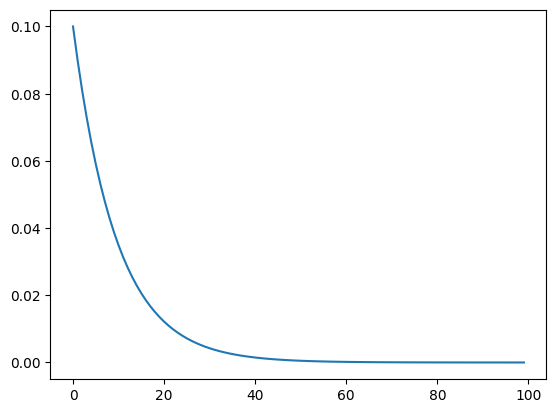

In [3]:
import torch
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# 定义模型和优化器
model = torch.nn.Linear(10, 2)  # 示例模型
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 定义 Lambda 函数
def lr_lambda(epoch):
    return 0.9 ** epoch  # 每个 epoch 学习率乘以 0.9

# 创建 LambdaLR 调度器
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda)

lr_his = schedular_lr(optimizer, scheduler)